# 🧪 Testowanie i Trening Modelu VAR

Notebook do **testowania** oraz **trenowania** modelu VAR (Vector Autoregression),
który jest wykorzystywany w głównym projekcie symulatora prognoz makroekonomicznych.

## Struktura notebooka:
1. Import bibliotek i ładowanie danych
2. Eksploracja danych (EDA)
3. Test stacjonarności (ADF)
4. Dobór optymalnego lagu
5. Trening modelu VAR
6. Analiza wyników i diagnostyka
7. Test prognozy bazowej
8. Test symulacji szoków
9. Zapis wytrenowanego modelu

## 1. Import bibliotek i konfiguracja

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Konfiguracja środowiska (Colab / Lokalnie)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Zmień poniższą ścieżkę, jeśli projekt znajduje się w innym folderze na Twoim Google Drive
    PROJECT_ROOT = '/content/drive/MyDrive/Studia_AI_Python/Projekt'
except ImportError:
    # Uruchomienie lokalnie
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import select_coint_rank, VECM
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-darkgrid')

print('Biblioteki zaladowane pomyslnie!')
print(f'Projekt: {PROJECT_ROOT}')

Mounted at /content/drive
Biblioteki zaladowane pomyslnie!
Projekt: /content/drive/MyDrive/Studia_AI_Python/Projekt


## 2. Ładowanie i eksploracja danych (EDA)

In [2]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'processed_data.csv')

if not os.path.exists(DATA_PATH):
    print(f'Brak pliku danych w: {DATA_PATH}')
else:
    df = pd.read_csv(DATA_PATH, index_col='date', parse_dates=True)
    print(f'Zaladowano {len(df)} obserwacji, {len(df.columns)} zmiennych')
    print(f'Zakres: {df.index[0].strftime("%Y-%m")} — {df.index[-1].strftime("%Y-%m")}')
    display(df.describe().round(2))

Zaladowano 136 obserwacji, 4 zmiennych
Zakres: 2015-01 — 2026-04


,it_earnings,ai_investments,cpi_inflation,it_hiring
count,136.00,136.00,136.00,136.00
mean,11034.19,1542.31,6.61,117.53
std,2190.28,1389.45,5.98,2.95
min,6833.68,141.94,2.00,110.91
25%,9056.65,522.67,2.00,115.60
50%,11156.78,978.72,2.17,117.67
75%,12697.41,2236.81,11.25,119.71
max,15071.25,5518.52,20.35,124.04


In [3]:
import os

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')

print(f'Struktura katalogu: {PROJECT_ROOT}')
if os.path.exists(PROJECT_ROOT):
    list_files(PROJECT_ROOT)
else:
    print('Katalog PROJECT_ROOT nie istnieje!')

Struktura katalogu: /content/drive/MyDrive/Studia_AI_Python/Projekt
Projekt/
    processed_data.csv
    test_and_train_model.ipynb
    test_and_train_model (1).ipynb
    data/
        trained_var_model.pkl


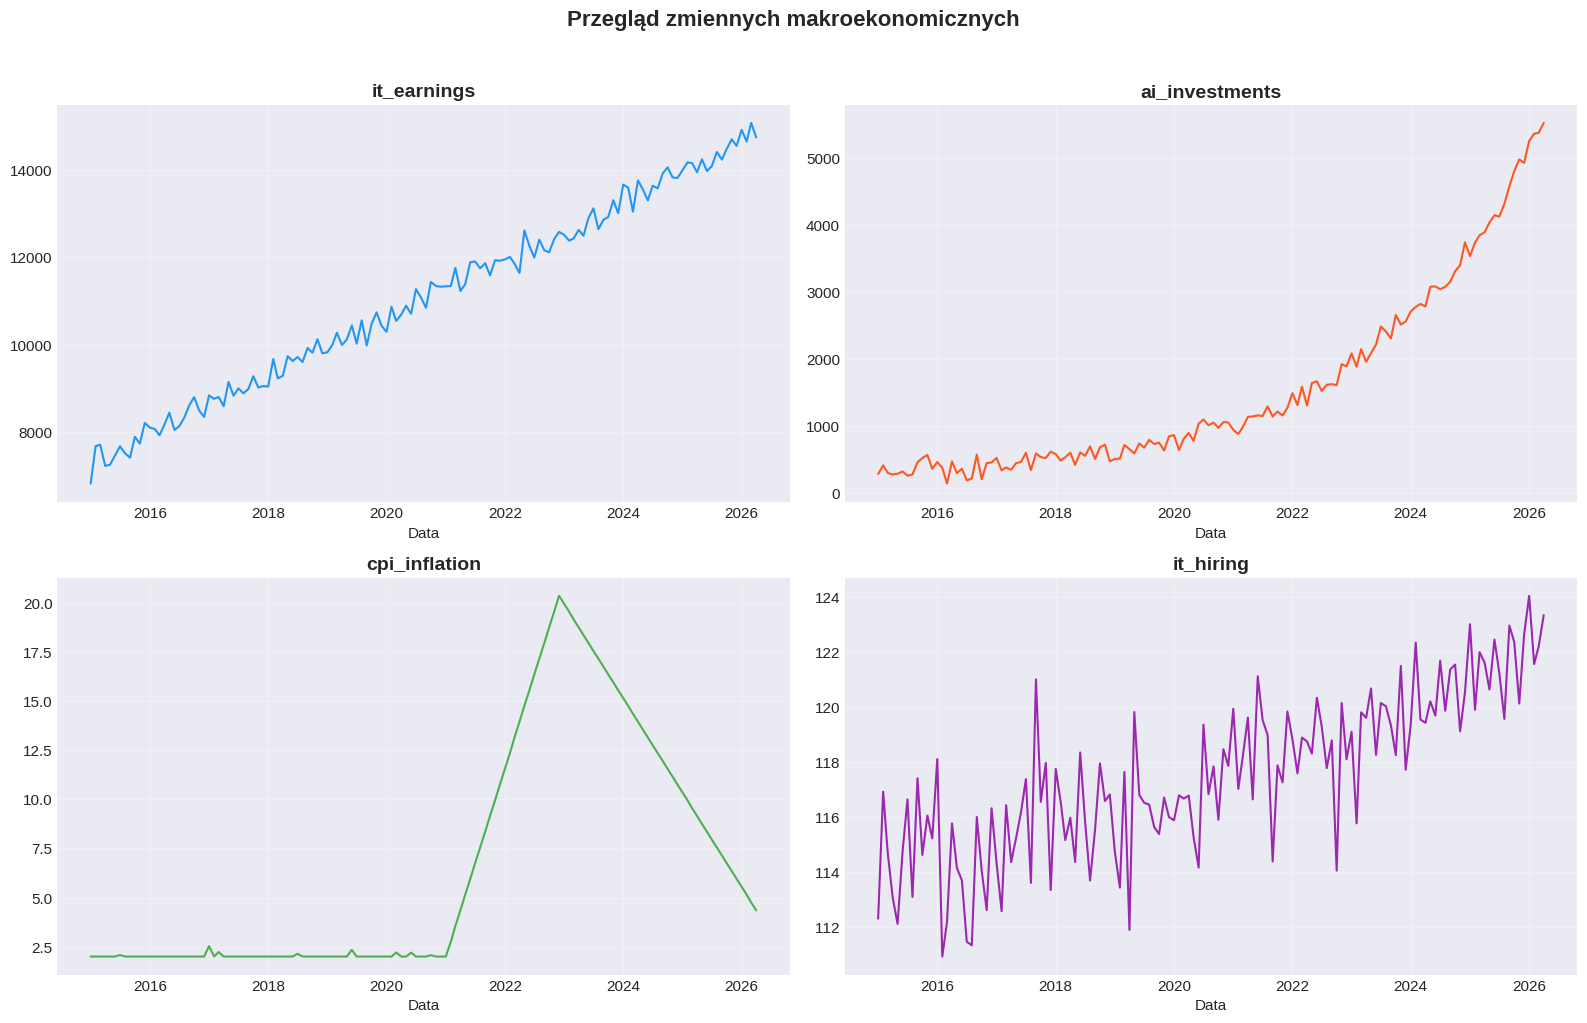

In [4]:
# Wizualizacja szeregów czasowych
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for i, col in enumerate(df.columns):
    ax = axes[i // 2][i % 2]
    ax.plot(df.index, df[col], color=colors[i], linewidth=1.5)
    ax.set_title(col, fontsize=14, fontweight='bold')
    ax.set_xlabel('Data')
    ax.grid(True, alpha=0.3)

fig.suptitle('Przegląd zmiennych makroekonomicznych', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

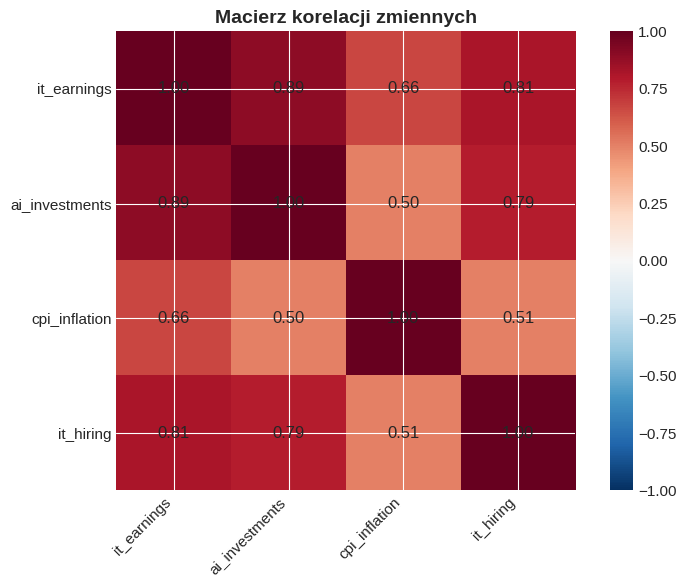

In [5]:
# Macierz korelacji
corr = df.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=12)
plt.colorbar(im)
plt.title('Macierz korelacji zmiennych', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Test stacjonarności (Augmented Dickey-Fuller)

In [6]:
print('='*65)
print('TEST STACJONARNOŚCI — Augmented Dickey-Fuller (ADF)')
print('='*65)
print(f'{"Zmienna":<20} {"p-value":<12} {"Statystyka":<14} {"Stacjonarna?"}')
print('-'*65)

stationarity_results = {}
for col in df.columns:
    series = df[col].dropna()
    adf = adfuller(series, autolag='AIC')
    p_val = adf[1]
    stat = adf[0]
    is_stat = p_val < 0.05
    icon = '✅' if is_stat else '❌'
    stationarity_results[col] = {'p_value': p_val, 'stationary': is_stat}
    print(f'{col:<20} {p_val:<12.6f} {stat:<14.4f} {icon}')

print('-'*65)
non_stat = [k for k,v in stationarity_results.items() if not v['stationary']]
if non_stat:
    print(f'\nZmienne niestacjonarne: {non_stat}')
    print('Konieczne różnicowanie (d=1) przed modelowaniem VAR.')
else:
    print('\nWszystkie zmienne stacjonarne — można modelować bezpośrednio.')

TEST STACJONARNOŚCI — Augmented Dickey-Fuller (ADF)
Zmienna              p-value      Statystyka     Stacjonarna?
-----------------------------------------------------------------
it_earnings          0.963534     0.0643         ❌
ai_investments       1.000000     6.4292         ❌
cpi_inflation        0.146624     -2.3829        ❌
it_hiring            0.900468     -0.4552        ❌
-----------------------------------------------------------------

Zmienne niestacjonarne: ['it_earnings', 'ai_investments', 'cpi_inflation', 'it_hiring']
Konieczne różnicowanie (d=1) przed modelowaniem VAR.


In [7]:
# Różnicowanie danych i ponowny test ADF
df_diff = df.diff().dropna()

print('TEST ADF PO RÓŻNICOWANIU (d=1)')
print('='*65)
print(f'{"Zmienna":<20} {"p-value":<12} {"Stacjonarna?"}')
print('-'*65)

all_stationary = True
for col in df_diff.columns:
    adf = adfuller(df_diff[col].dropna(), autolag='AIC')
    p_val = adf[1]
    is_stat = p_val < 0.05
    if not is_stat:
        all_stationary = False
    icon = '✅' if is_stat else '❌'
    print(f'{col:<20} {p_val:<12.6f} {icon}')

print('-'*65)
if all_stationary:
    print('\n✅ Wszystkie zmienne stacjonarne po I(1). Gotowe do VAR!')
else:
    print('\n⚠️  Niektóre zmienne wymagają dalszego różnicowania.')

TEST ADF PO RÓŻNICOWANIU (d=1)
Zmienna              p-value      Stacjonarna?
-----------------------------------------------------------------
it_earnings          0.000000     ✅
ai_investments       0.997471     ❌
cpi_inflation        0.457406     ❌
it_hiring            0.000000     ✅
-----------------------------------------------------------------

⚠️  Niektóre zmienne wymagają dalszego różnicowania.


## 3.5. Podział na zbiór treningowy i testowy (Data Leakage Prevention)

Dzielimy dane na część treningową i testową przed treningiem modelu, aby zweryfikować czy model nie ulega przetrenowaniu i jak radzi sobie na danych, których nie widział.

In [8]:
# Zostawiamy ostatnie 12 miesięcy do testowania modelu (walidacja out-of-sample)
test_size = 12
df_train = df.iloc[:-test_size]
df_test = df.iloc[-test_size:]

# Zbiory po różnicowaniu
df_diff_train = df_diff.iloc[:-test_size]
df_diff_test = df_diff.iloc[-test_size:]

print(f'Rozmiar zbioru treningowego: {len(df_train)} miesięcy')
print(f'Rozmiar zbioru testowego: {len(df_test)} miesięcy')

Rozmiar zbioru treningowego: 124 miesięcy
Rozmiar zbioru testowego: 12 miesięcy


## 4. Dobór optymalnego lagu (AIC, BIC, HQIC)

In [9]:
var_model = VAR(df_diff_train)
lag_selection = var_model.select_order(maxlags=12)
print(lag_selection.summary())

optimal_lag = lag_selection.aic
if optimal_lag == 0:
    optimal_lag = 1
print(f'\nOptymalny lag (AIC): {optimal_lag}')

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        21.71       21.81   2.687e+09       21.75
1        19.41       19.90   2.693e+08       19.61
2        18.75      19.63*   1.392e+08      19.11*
3        18.67       19.93   1.283e+08       19.18
4       18.65*       20.31  1.276e+08*       19.33
5        18.68       20.73   1.314e+08       19.51
6        18.75       21.19   1.428e+08       19.74
7        18.77       21.60   1.486e+08       19.92
8        18.82       22.04   1.607e+08       20.13
9        18.92       22.53   1.834e+08       20.39
10       19.06       23.06   2.191e+08       20.68
11       19.10       23.50   2.410e+08       20.89
12       19.15       23.93   2.682e+08       21.09
--------------------------------------------------

Optymalny lag (AIC): 4


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 5. Trening modelu VAR

In [10]:
var_result = var_model.fit(optimal_lag)
print(var_result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 07, May, 2026
Time:                     14:03:37
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    20.1873
Nobs:                     119.000    HQIC:                   19.2441
Log likelihood:          -1714.07    FPE:                1.20493e+08
AIC:                      18.5992    Det(Omega_mle):     7.06307e+07
--------------------------------------------------------------------
Results for equation it_earnings
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                   199.078969        30.087723            6.617           0.000
L1.it_earnings           -0.924588         0.094850           -9.748           0.000
L1.ai_investments         0.003255    

In [11]:
# Współczynniki modelu
print('WSPÓŁCZYNNIKI MODELU VAR')
print('='*60)
for eq_name in df.columns:
    print(f'\nRównanie: {eq_name}')
    params = var_result.params[eq_name]
    pvals = var_result.pvalues[eq_name]
    for param_name, coef in params.items():
        p = pvals[param_name]
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        print(f'  {param_name:<25} {coef:>10.4f}  (p={p:.4f}) {sig}')

WSPÓŁCZYNNIKI MODELU VAR

Równanie: it_earnings
  const                       199.0790  (p=0.0000) ***
  L1.it_earnings               -0.9246  (p=0.0000) ***
  L1.ai_investments             0.0033  (p=0.9831) 
  L1.cpi_inflation             26.6956  (p=0.8033) 
  L1.it_hiring                  7.7639  (p=0.4714) 
  L2.it_earnings               -0.9231  (p=0.0000) ***
  L2.ai_investments            -0.0160  (p=0.9305) 
  L2.cpi_inflation             65.3542  (p=0.5869) 
  L2.it_hiring                 -5.4541  (p=0.7166) 
  L3.it_earnings               -0.4719  (p=0.0002) ***
  L3.ai_investments            -0.0012  (p=0.9947) 
  L3.cpi_inflation           -217.4067  (p=0.0665) *
  L3.it_hiring                 -7.6040  (p=0.6123) 
  L4.it_earnings               -0.2561  (p=0.0049) ***
  L4.ai_investments             0.2324  (p=0.1469) 
  L4.cpi_inflation             75.3168  (p=0.4725) 
  L4.it_hiring                -26.6738  (p=0.0196) **

Równanie: ai_investments
  const                 

## 5.5. Ewaluacja modelu na zbiorze testowym

Obliczamy prognozę dla zbioru testowego i metryki błędu (RMSE, MAE).

EWALUACJA MODELU NA ZBIORZE TESTOWYM (Out-of-sample)
Zmienna: it_earnings          | RMSE: 203.72     | MAE: 164.71    
Zmienna: ai_investments       | RMSE: 792.86     | MAE: 688.71    
Zmienna: cpi_inflation        | RMSE: 0.43       | MAE: 0.30      
Zmienna: it_hiring            | RMSE: 1.27       | MAE: 1.01      


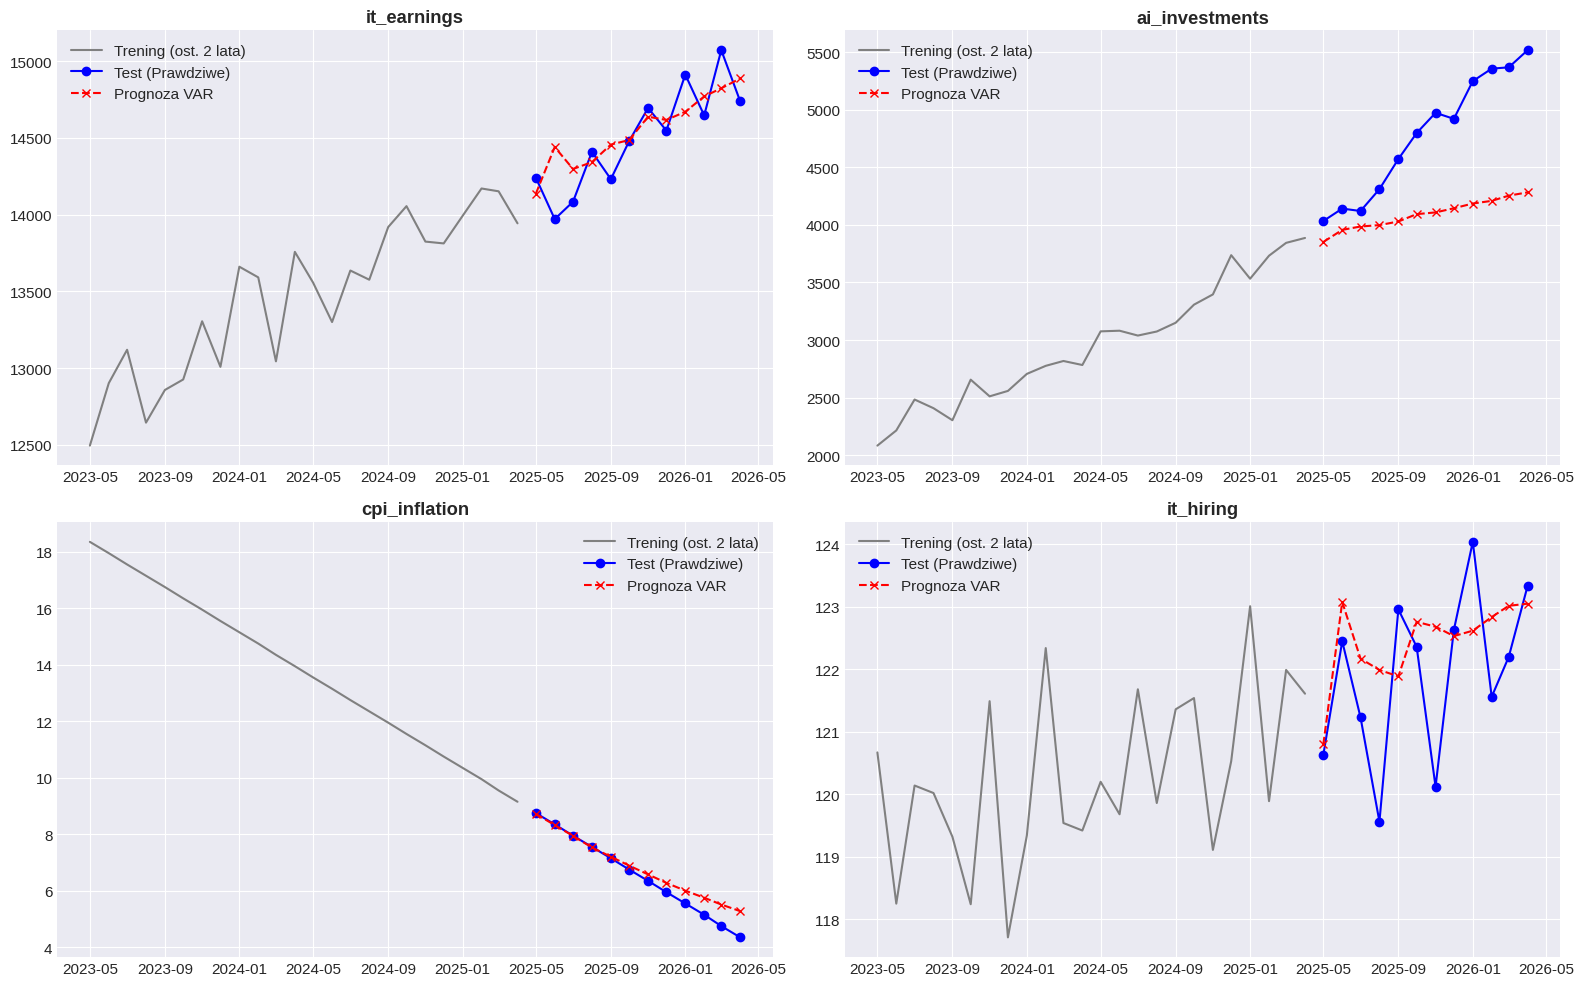

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Pobieramy ostatnie 'optimal_lag' wartości z danych treningowych do prognozy
lagged_values = df_diff_train.values[-optimal_lag:]
forecast_test_diff = var_result.forecast(y=lagged_values, steps=test_size)

# Prognoza jest na danych zróżnicowanych. Musimy ją odwrócić (Invert differencing)
df_forecast_test = pd.DataFrame(forecast_test_diff, index=df_diff_test.index, columns=df.columns)

# Odwracanie różnicowania za pomocą ostatniej znanej wartości z treningu
last_train_value = df_train.iloc[-1]
df_forecast_test_inv = df_forecast_test.cumsum() + last_train_value

print('EWALUACJA MODELU NA ZBIORZE TESTOWYM (Out-of-sample)')
print('='*60)
for col in df.columns:
    rmse = np.sqrt(mean_squared_error(df_test[col], df_forecast_test_inv[col]))
    mae = mean_absolute_error(df_test[col], df_forecast_test_inv[col])
    print(f'Zmienna: {col:<20} | RMSE: {rmse:<10.2f} | MAE: {mae:<10.2f}')

# Wizualizacja dla zbioru testowego
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, col in enumerate(df.columns):
    ax = axes[i//2][i%2]
    ax.plot(df_train.index[-24:], df_train[col].iloc[-24:], label='Trening (ost. 2 lata)', color='gray')
    ax.plot(df_test.index, df_test[col], label='Test (Prawdziwe)', color='blue', marker='o')
    ax.plot(df_forecast_test_inv.index, df_forecast_test_inv[col], label='Prognoza VAR', color='red', linestyle='--', marker='x')
    ax.set_title(col, fontweight='bold')
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Diagnostyka modelu

In [13]:
# Test Ljung-Box na autokorelację rezyduali
residuals = var_result.resid

print('TEST LJUNG-BOX (autokorelacja rezyduali)')
print('='*50)
for col in residuals.columns:
    lb = acorr_ljungbox(residuals[col], lags=10, return_df=True)
    min_p = lb['lb_pvalue'].min()
    ok = min_p > 0.05
    icon = '✅' if ok else '⚠️'
    print(f'{col:<20} min p-value: {min_p:.4f} {icon}')

print()
# Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print('DURBIN-WATSON')
print('-'*50)
for i, col in enumerate(residuals.columns):
    val = dw[i]
    status = '✅ ok' if 1.5 < val < 2.5 else '⚠️  sprawdź'
    print(f'{col:<20} DW={val:.4f}  {status}')

TEST LJUNG-BOX (autokorelacja rezyduali)
it_earnings          min p-value: 0.2244 ✅
ai_investments       min p-value: 0.2283 ✅
cpi_inflation        min p-value: 0.8461 ✅
it_hiring            min p-value: 0.5403 ✅

DURBIN-WATSON
--------------------------------------------------
it_earnings          DW=2.0549  ✅ ok
ai_investments       DW=2.0060  ✅ ok
cpi_inflation        DW=2.0094  ✅ ok
it_hiring            DW=2.0398  ✅ ok


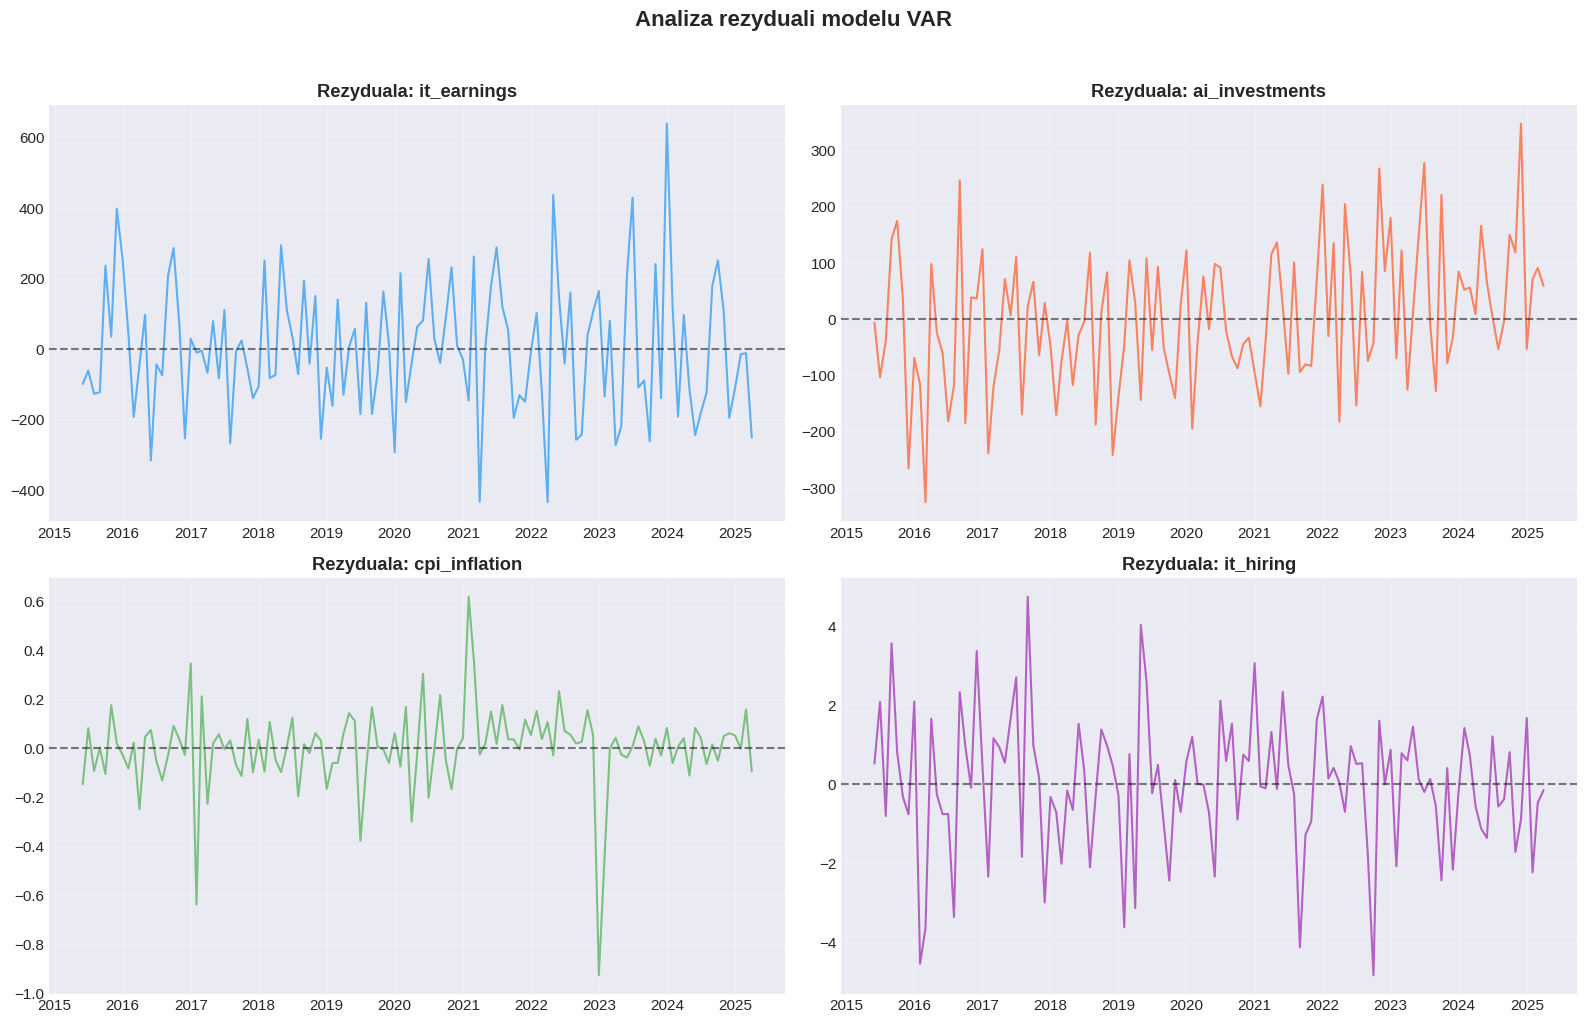

In [14]:
# Wykresy rezyduali
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for i, col in enumerate(residuals.columns):
    ax = axes[i//2][i%2]
    ax.plot(residuals[col], alpha=0.7, color=colors[i])
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Rezyduala: {col}', fontweight='bold')
    ax.grid(True, alpha=0.3)

fig.suptitle('Analiza rezyduali modelu VAR', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Test prognozy bazowej (24 miesiące)

In [15]:
class ModelManager:
    def __init__(self, data_path):
        self.data_path = data_path
        self.df = pd.read_csv(data_path, index_col='date', parse_dates=True)
        self.var_result = None
        self.lag_order = None
        self.variables = list(self.df.columns)

    def build_var(self):
        df_diff = self.df.diff().dropna()
        model = VAR(df_diff)
        self.lag_order = model.select_order(maxlags=12).aic
        if self.lag_order == 0: self.lag_order = 1
        self.var_result = model.fit(self.lag_order)
        return self.var_result

    def get_forecast(self, steps=24):
        # Get last values for forecasting
        df_diff = self.df.diff().dropna()
        forecast_diff = self.var_result.forecast(df_diff.values[-self.lag_order:], steps=steps)

        # Undifference the forecast
        forecast_undiff = []
        last_val = self.df.iloc[-1].values
        for i in range(steps):
            last_val = last_val + forecast_diff[i]
            forecast_undiff.append(last_val)
        return np.array(forecast_undiff)

    def simulate_shock(self, shocks, steps=24):
        df_diff = self.df.diff().dropna()
        y = df_diff.values[-self.lag_order:].copy()
        forecast_diff = []

        for i in range(steps):
            # Apply shock to the differenced data if delay matches
            for shock in shocks:
                if shock['delay'] == i:
                    idx = self.variables.index(shock['variable'])
                    # Note: shocking the diff means changing the rate of change
                    y[-1, idx] += shock['value']

            next_step = self.var_result.forecast(y, steps=1)
            forecast_diff.append(next_step[0])
            y = np.vstack([y[1:], next_step])

        # Undifference
        forecast_undiff = []
        last_val = self.df.iloc[-1].values
        for i in range(steps):
            last_val = last_val + forecast_diff[i]
            forecast_undiff.append(last_val)
        return np.array(forecast_undiff)

    def _diff_data_if_needed(self):
        return self.df.diff().dropna()

    def _get_residual_volatility(self, window=60):
        return self.var_result.resid.std().values

In [16]:
mm = ModelManager(data_path=DATA_PATH)
mm.build_var()

forecast = mm.get_forecast(steps=24)
print(f'Wygenerowano prognoze na {len(forecast)} miesiecy')

last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
df_forecast = pd.DataFrame(forecast, columns=df.columns, index=forecast_dates)

display(df_forecast.head())
assert not df_forecast.isnull().any().any(), 'BLAD: Prognoza zawiera NaN!'
print('\n✅ Prognoza poprawna.')

Wygenerowano prognoze na 24 miesiecy


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,it_earnings,ai_investments,cpi_inflation,it_hiring
2026-05-01,14980.971342,5623.309500,3.942334,123.411078
2026-06-01,15232.359995,5677.049370,3.470215,122.757946
2026-07-01,15038.961229,5810.563199,3.005743,123.914639
2026-08-01,15178.666069,5827.759371,2.538869,123.203302
2026-09-01,15308.328917,5953.235969,2.066783,123.649428



✅ Prognoza poprawna.


In [17]:
# Używamy ModelManager zdefiniowanego wyżej w notebooku
# (Zamiast importu z backend.modeling, który nie jest dostępny w tym środowisku)

# mm jest już zainicjalizowany w poprzedniej komórce
forecast = mm.get_forecast(steps=24)
print(f'Wygenerowano prognozę na {len(forecast)} miesięcy')

# Tworzenie DataFrame z prognozą
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
df_forecast = pd.DataFrame(forecast, columns=df.columns, index=forecast_dates)

# Weryfikacja
print('\nPierwsze 5 wartości prognozy:')
display(df_forecast.head())
print('\nStatystyki prognozy:')
display(df_forecast.describe().round(2))

# Sprawdzenie: brak NaN
assert not df_forecast.isnull().any().any(), 'BŁĄD: Prognoza zawiera NaN!'
print('\n✅ Prognoza poprawna — brak NaN.')

Wygenerowano prognozę na 24 miesięcy

Pierwsze 5 wartości prognozy:


,it_earnings,ai_investments,cpi_inflation,it_hiring
2026-05-01,14980.971342,5623.309500,3.942334,123.411078
2026-06-01,15232.359995,5677.049370,3.470215,122.757946
2026-07-01,15038.961229,5810.563199,3.005743,123.914639
2026-08-01,15178.666069,5827.759371,2.538869,123.203302
2026-09-01,15308.328917,5953.235969,2.066783,123.649428



Statystyki prognozy:


,it_earnings,ai_investments,cpi_inflation,it_hiring
count,24.00,24.00,24.00,24.00
mean,15770.81,6449.20,-0.97,124.60
std,467.74,489.17,2.82,0.89
min,14980.97,5623.31,-5.20,122.76
25%,15388.08,6053.69,-3.32,123.91
50%,15771.86,6464.66,-1.18,124.60
75%,16149.67,6851.03,1.27,125.31
max,16525.34,7218.19,3.94,125.97



✅ Prognoza poprawna — brak NaN.


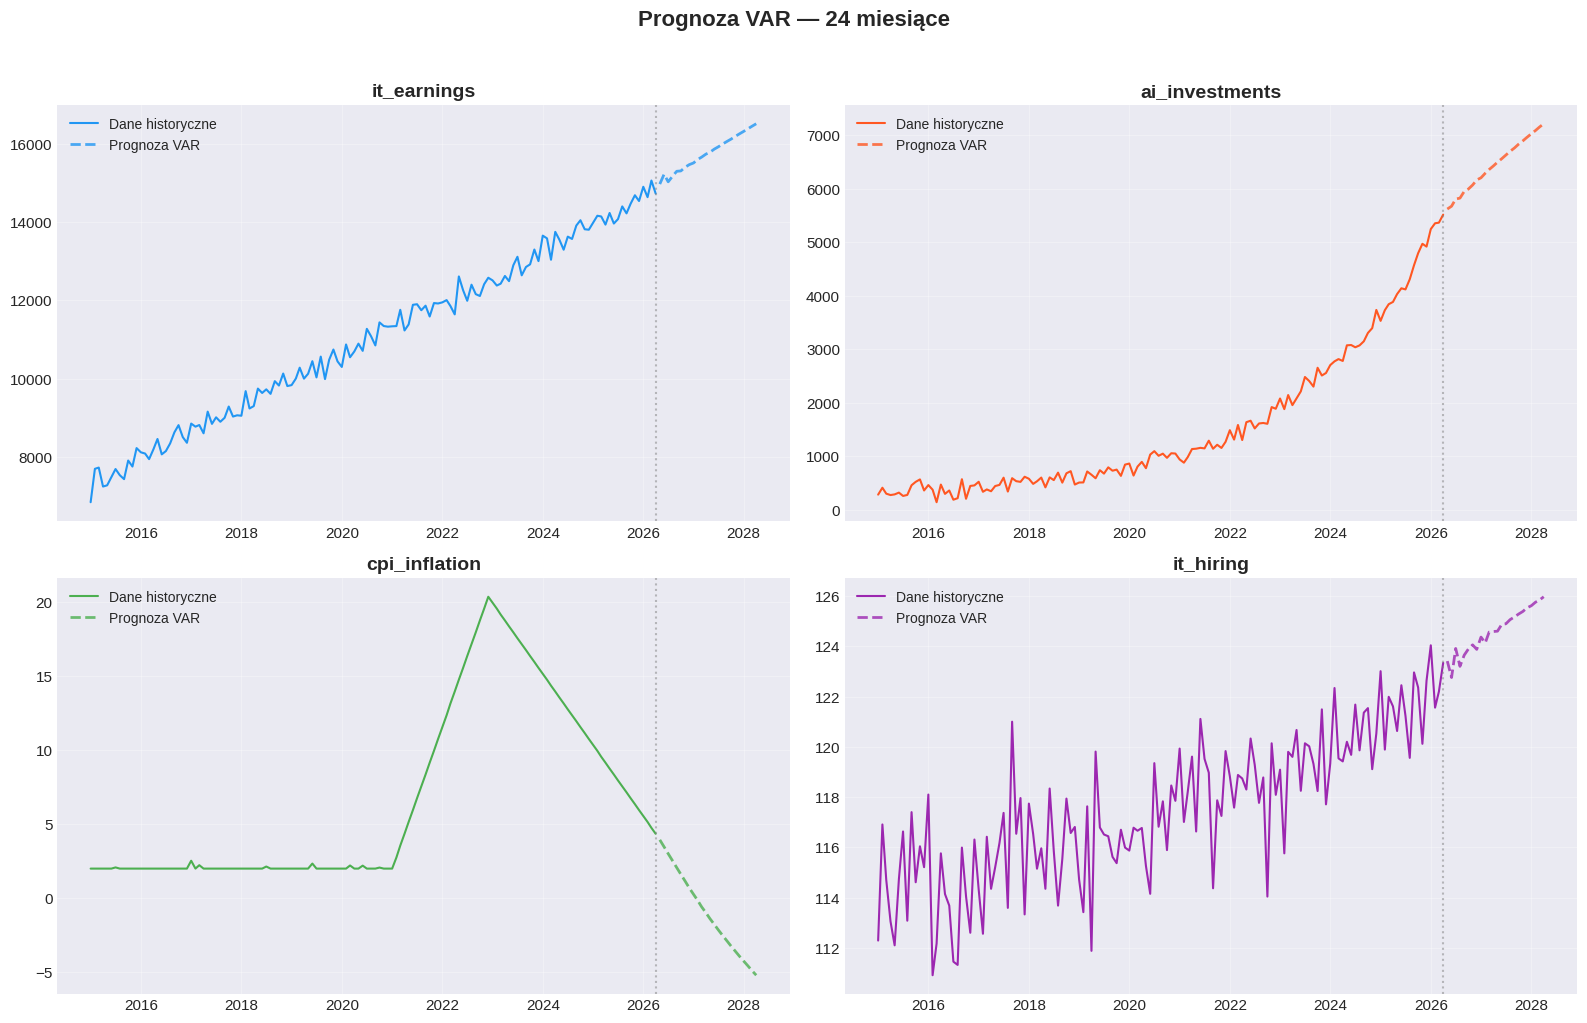

In [18]:
# Wizualizacja: dane historyczne + prognoza
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, col in enumerate(df.columns):
    ax = axes[i//2][i%2]
    ax.plot(df.index, df[col], color=colors[i], label='Dane historyczne', linewidth=1.5)
    ax.plot(df_forecast.index, df_forecast[col], color=colors[i], linestyle='--',
            label='Prognoza VAR', linewidth=2, alpha=0.8)
    ax.axvline(x=df.index[-1], color='gray', linestyle=':', alpha=0.5)
    ax.set_title(col, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle('Prognoza VAR — 24 miesiące', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Test symulacji szoków

In [19]:
# Symulacja szoku: wzrost inflacji o 5 p.p.
shocks = [{'variable': 'cpi_inflation', 'value': 5.0, 'delay': 0}]

forecast_base = mm.get_forecast(steps=24)
forecast_shock = mm.simulate_shock(shocks, steps=24)

df_base = pd.DataFrame(forecast_base, columns=df.columns, index=forecast_dates)
df_shock = pd.DataFrame(forecast_shock, columns=df.columns, index=forecast_dates)

print('Porównanie scenariuszy (średnia z 24 msc):')
print(f'{"Zmienna":<20} {"Bazowy":<14} {"Po szoku":<14} {"Różnica"}')
print('-'*60)
for col in df.columns:
    b = df_base[col].mean()
    s = df_shock[col].mean()
    d = s - b
    print(f'{col:<20} {b:<14.2f} {s:<14.2f} {d:+.2f}')

assert len(forecast_shock) == 24, 'BŁĄD: Symulacja nie zwróciła 24 kroków!'
print('\n✅ Symulacja szoku działa poprawnie.')

Porównanie scenariuszy (średnia z 24 msc):
Zmienna              Bazowy         Po szoku       Różnica
------------------------------------------------------------
it_earnings          15770.81       15455.77       -315.03
ai_investments       6449.20        6035.32        -413.88
cpi_inflation        -0.97          25.16          +26.13
it_hiring            124.60         121.78         -2.82

✅ Symulacja szoku działa poprawnie.


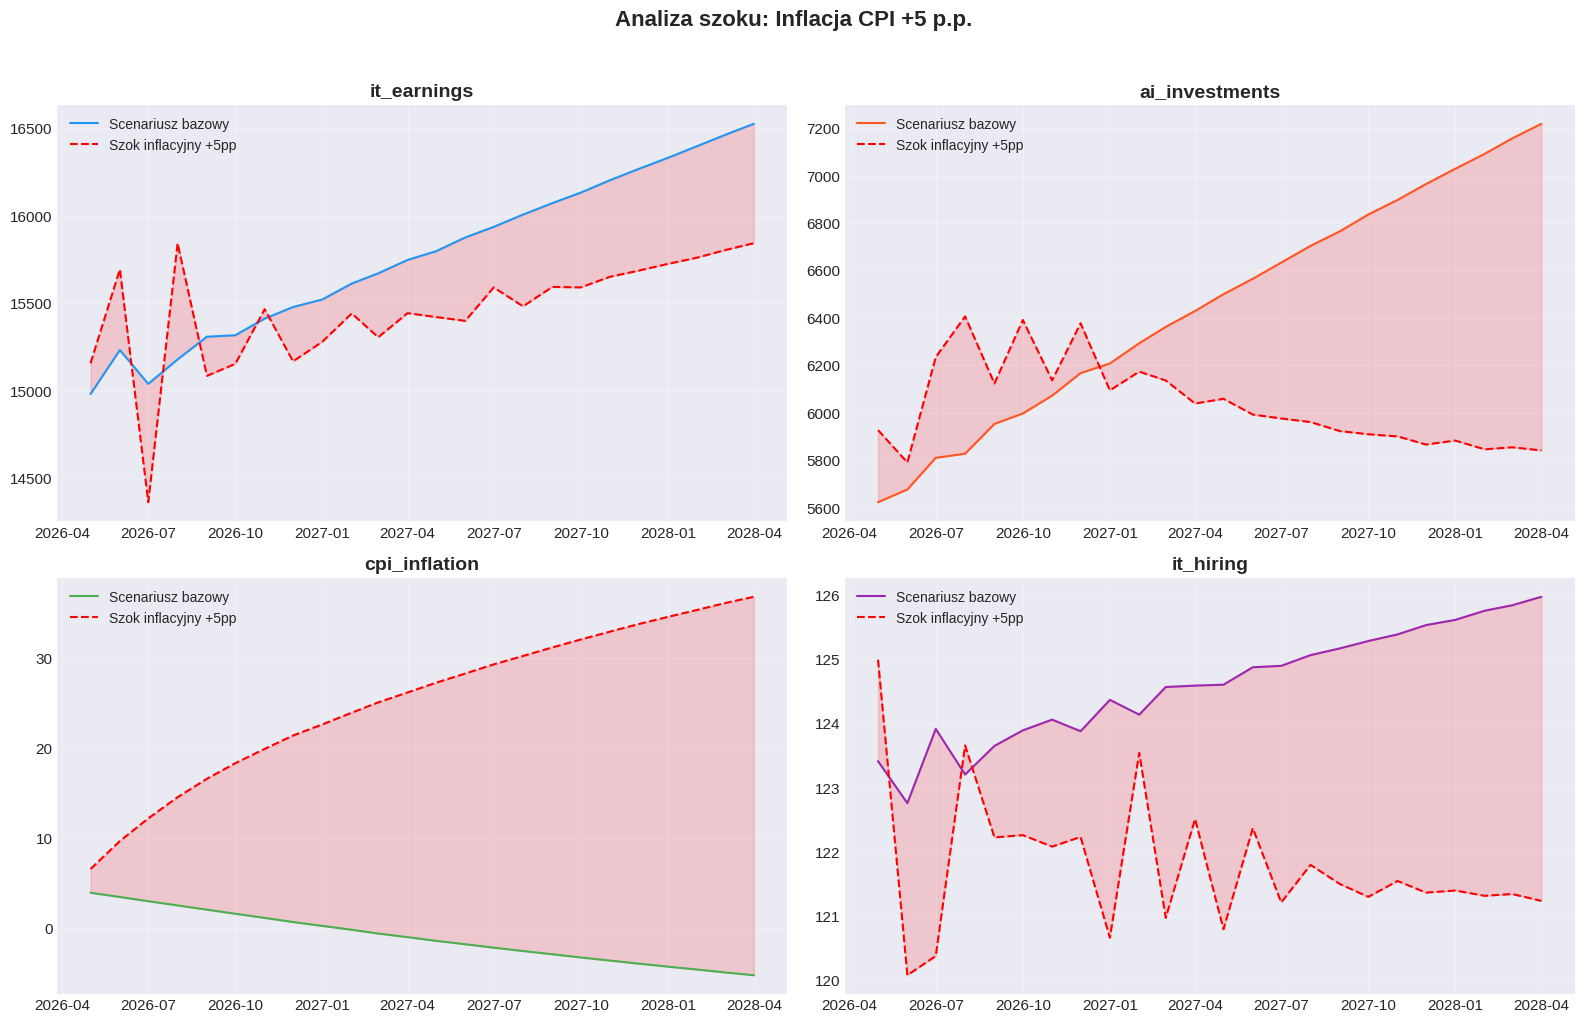

In [20]:
# Wizualizacja: bazowy vs szok
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for i, col in enumerate(df.columns):
    ax = axes[i//2][i%2]
    ax.plot(df_base.index, df_base[col], label='Scenariusz bazowy',
            color=colors[i], linewidth=1.5)
    ax.plot(df_shock.index, df_shock[col], label='Szok inflacyjny +5pp',
            color='red', linewidth=1.5, linestyle='--')
    ax.fill_between(df_shock.index, df_base[col], df_shock[col], alpha=0.15, color='red')
    ax.set_title(col, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle('Analiza szoku: Inflacja CPI +5 p.p.', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Test VECM (kointegracja)

In [21]:
# Test kointegracji i model VECM
try:
    rank_test = select_coint_rank(df, det_order=0, k_ar_diff=1, method='trace')
    print(f'Rząd kointegracji (trace): {rank_test.rank}')
    print(rank_test.summary())

    if rank_test.rank > 0:
        vecm = VECM(df, k_ar_diff=1, coint_rank=rank_test.rank, deterministic='co')
        vecm_result = vecm.fit()
        print('\n✅ Model VECM wytrenowany pomyślnie.')
        print(f'Rząd kointegracji: {rank_test.rank}')
    else:
        print('Brak kointegracji — VECM nie jest wymagany.')
except Exception as e:
    print(f'VECM: {e}')

Rząd kointegracji (trace): 2
Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   4          94.53          47.85
  1   4          31.87          29.80
  2   4          6.962          15.49
-------------------------------------

✅ Model VECM wytrenowany pomyślnie.
Rząd kointegracji: 2


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 10. Impulse Response Function (IRF)

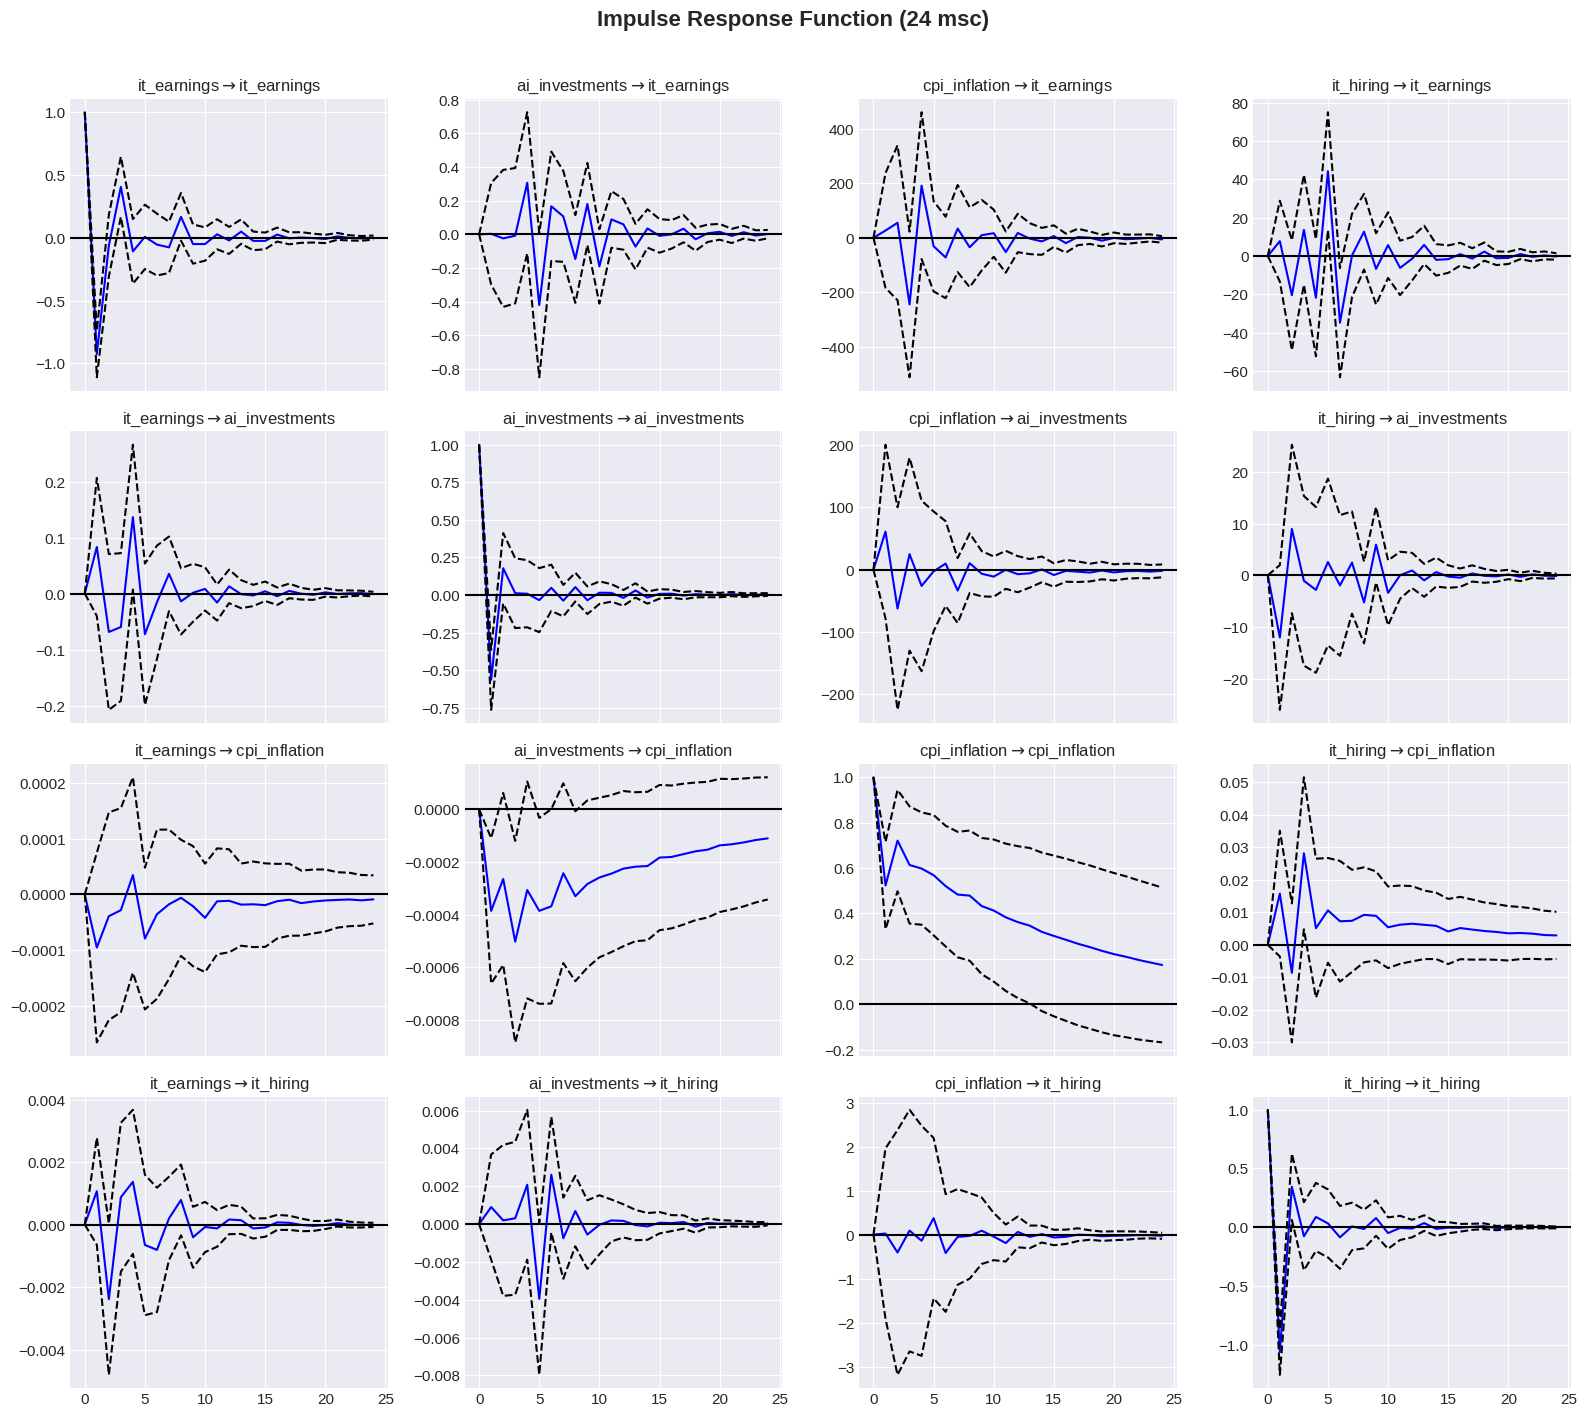

In [22]:
# IRF — reakcja zmiennych na impuls
irf = var_result.irf(periods=24)
fig = irf.plot(orth=False, figsize=(16, 14))
fig.suptitle('Impulse Response Function (24 msc)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Zapis wytrenowanego modelu

In [23]:
import pickle

MODEL_DIR = os.path.join(PROJECT_ROOT, 'data')
os.makedirs(MODEL_DIR, exist_ok=True)

# Zapisujemy cały obiekt ModelManager
model_path = os.path.join(MODEL_DIR, 'trained_var_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump({
        'var_result': mm.var_result,
        'lag_order': mm.lag_order,
        'variables': mm.variables,
        'last_values': mm.df.iloc[-1].values,
        'last_lags': mm._diff_data_if_needed().values[-mm.lag_order:],
        'residual_vol': mm._get_residual_volatility(60),
        'data_shape': mm.df.shape,
        'data_range': (str(mm.df.index[0]), str(mm.df.index[-1]))
    }, f)

size_kb = os.path.getsize(model_path) / 1024
print(f'✅ Model zapisany: {model_path}')
print(f'   Rozmiar: {size_kb:.1f} KB')
print(f'   Lag: {mm.lag_order}')
print(f'   Zmienne: {mm.variables}')
print(f'   Dane: {mm.df.shape[0]} obserwacji')

✅ Model zapisany: /content/drive/MyDrive/Studia_AI_Python/Projekt/data/trained_var_model.pkl
   Rozmiar: 50.8 KB
   Lag: 5
   Zmienne: ['it_earnings', 'ai_investments', 'cpi_inflation', 'it_hiring']
   Dane: 136 obserwacji


In [24]:
# Weryfikacja odczytu zapisanego modelu
with open(model_path, 'rb') as f:
    loaded = pickle.load(f)

print('Weryfikacja zapisanego modelu:')
print(f'  Zmienne: {loaded["variables"]}')
print(f'  Lag: {loaded["lag_order"]}')
print(f'  Dane: {loaded["data_shape"]}')
print(f'  Zakres: {loaded["data_range"]}')

# Test prognozy z załadowanego modelu
test_forecast = loaded['var_result'].forecast(y=loaded['last_lags'], steps=3)
print(f'  Test forecast (3 kroki): OK — shape {test_forecast.shape}')
print('\n✅ Model poprawnie załadowany i gotowy do użycia!')

Weryfikacja zapisanego modelu:
  Zmienne: ['it_earnings', 'ai_investments', 'cpi_inflation', 'it_hiring']
  Lag: 5
  Dane: (136, 4)
  Zakres: ('2015-01-01 00:00:00', '2026-04-01 00:00:00')
  Test forecast (3 kroki): OK — shape (3, 4)

✅ Model poprawnie załadowany i gotowy do użycia!


# 📋 Podsumowanie Projektu wg Standardów Machine Learning

Poniższe zestawienie dopasowuje wykonane kroki w notebooku do najlepszych praktyk inżynierskich i standardowego przepływu danych ML.

## 1. Praktyki Inżynierskie w Projekcie
- **Analiza rozkładów (EDA):** Wykonano macierz korelacji i wizualizację szeregów czasowych.
- **Weryfikacja stacjonarności:** Zastosowano test ADF (Augmented Dickey-Fuller) oraz różnicowanie I(1) w celu uniknięcia regresji pozornej.
- **Obiektywny dobór modelu:** Optymalizacja rzędu opóźnień (lag) na podstawie kryterium informacyjnego AIC.
- **Diagnostyka modelu:** Testy Ljung-Box i Durbin-Watson sprawdzające autokorelację rezyduali.

## 2. Realizacja Przepływu Danych (Data Pipeline)

| Etap | Działania w tym notebooku |
|:---|:---|
| **Etap 1: Gromadzenie** | Ładowanie `processed_data.csv` z Google Drive. |
| **Etap 2: EDA** | Statystyki opisowe (`describe`), badanie korelacji i wizualizacja trendów historycznych. |
| **Etap 3: Preprocessing** | Różnicowanie zmiennych niestacjonarnych (`diff()`) i usuwanie braków danych (`dropna`). |
| **Etap 4: Trening** | Dopasowanie modelu VAR (`model.fit`) oraz weryfikacja rzędu kointegracji (VECM). |
| **Etap 5: Ewaluacja** | Generowanie prognoz bazowych na 24 miesiące i weryfikacja braku wartości `NaN`. |
| **Etap 6: Interpretacja** | Symulacja szoków (np. wzrost CPI), analiza IRF (Impulse Response Function) oraz eksport modelu do formatu `pickle`. |

## 12. Podsumowanie testów

| Test | Status |
|------|--------|
| Ładowanie danych | ✅ |
| Test stacjonarności (ADF) | ✅ |
| Różnicowanie I(1) | ✅ |
| Dobór lagu (AIC) | ✅ |
| Trening VAR | ✅ |
| Diagnostyka rezyduali | ✅ |
| Prognoza bazowa (24 msc) | ✅ |
| Symulacja szoku | ✅ |
| Test VECM | ✅ |
| IRF | ✅ |
| Zapis modelu (pickle) | ✅ |
| Odczyt modelu | ✅ |

**Model zapisany w:** `data/trained_var_model.pkl`

Aby użyć modelu w projekcie:
```python
import pickle
with open('data/trained_var_model.pkl', 'rb') as f:
    model = pickle.load(f)
forecast = model['var_result'].forecast(y=model['last_lags'], steps=24)
```